In [20]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [21]:
DATASET_PATH = "DataGenLett"

In [22]:
def clean_image(image, target_size):
    """
    Nettoie et prétraite une image pour la réduire au bruit et ajuster la taille.
    """
    img_resized = cv2.resize(image, target_size)
    return img_resized

In [28]:
def loadset(path_name, img_size=(35, 35), grayscale=True, num_images=None):
    """
    Charge et prétraite les images d'un chemin spécifié, qui contient des sous-dossiers de classes.
    """
    X = []
    Y = []
    class_indices = {}
    
    class_names = sorted(os.listdir(path_name))
    class_indices = {name: idx for idx, name in enumerate(class_names)}
    
    for class_name, class_index in class_indices.items():
        class_path = os.path.join(path_name, class_name)
        if not os.path.exists(class_path):
            print(f"⚠ Le dossier {class_path} n'existe pas, il sera ignoré.")
            continue
        if os.path.isdir(class_path):
            images = os.listdir(class_path)
            if num_images:
                images = images[:num_images]
            
            image_count = 0
            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                
                if img is None:
                    print(f"⚠ Impossible de lire {img_path}, il sera ignoré.")
                    continue
                
                img_processed = clean_image(img, img_size)
                X.append(img_processed)
                Y.append(class_index)
                image_count += 1
            
            print(f"> 📂 Classe {class_name} ({class_index}) chargée avec {image_count} images.")
        else:
            print(f"⚠ {class_path} n'est pas un dossier.")
    
    print("\n✅ Chargement terminé !")
    return np.array(X), np.array(Y), class_indices

In [29]:
X, Y, class_indices = loadset(DATASET_PATH, grayscale=True, num_images=1000)


⚠ DataGenLett/.DS_Store n'est pas un dossier.
⚠ Impossible de lire DataGenLett/a/.DS_Store, il sera ignoré.
> 📂 Classe a (1) chargée avec 999 images.
> 📂 Classe b (2) chargée avec 1000 images.
> 📂 Classe c (3) chargée avec 1000 images.
> 📂 Classe d (4) chargée avec 1000 images.
> 📂 Classe dd (5) chargée avec 1000 images.
> 📂 Classe e (6) chargée avec 1000 images.
> 📂 Classe f (7) chargée avec 1000 images.
> 📂 Classe g (8) chargée avec 1000 images.
> 📂 Classe h (9) chargée avec 1000 images.
> 📂 Classe i (10) chargée avec 1000 images.
> 📂 Classe j (11) chargée avec 1000 images.
> 📂 Classe k (12) chargée avec 1000 images.
> 📂 Classe l (13) chargée avec 1000 images.
> 📂 Classe m (14) chargée avec 1000 images.
> 📂 Classe n (15) chargée avec 1000 images.
⚠ Impossible de lire DataGenLett/o/o1_213.jpg, il sera ignoré.
> 📂 Classe o (16) chargée avec 999 images.
⚠ Impossible de lire DataGenLett/p/p2_103.jpg, il sera ignoré.
⚠ Impossible de lire DataGenLett/p/p5_188.jpg, il sera ignoré.
> 📂 Class

In [25]:
X

array([[[235, 247, 227, ..., 225, 246, 219],
        [227, 243, 232, ..., 232, 243, 221],
        [236, 227, 231, ..., 235, 233, 224],
        ...,
        [229, 234, 247, ..., 227, 229, 231],
        [229, 236, 246, ..., 234, 230, 227],
        [230, 237, 244, ..., 236, 234, 236]],

       [[229, 230, 239, ..., 228, 216, 232],
        [232, 219, 229, ..., 242, 238, 241],
        [233, 236, 240, ..., 241, 243, 243],
        ...,
        [252, 245, 236, ..., 234, 245, 239],
        [229, 232, 235, ..., 235, 239, 231],
        [238, 232, 227, ..., 243, 239, 226]],

       [[225, 237, 242, ..., 232, 247, 236],
        [230, 233, 238, ..., 232, 237, 227],
        [236, 231, 232, ..., 250, 244, 222],
        ...,
        [237, 228, 239, ..., 234, 230, 230],
        [236, 217, 231, ..., 235, 234, 238],
        [245, 227, 230, ..., 228, 231, 236]],

       ...,

       [[226, 238, 236, ..., 224, 231, 240],
        [243, 231, 230, ..., 239, 233, 236],
        [234, 240, 243, ..., 229, 231, 248

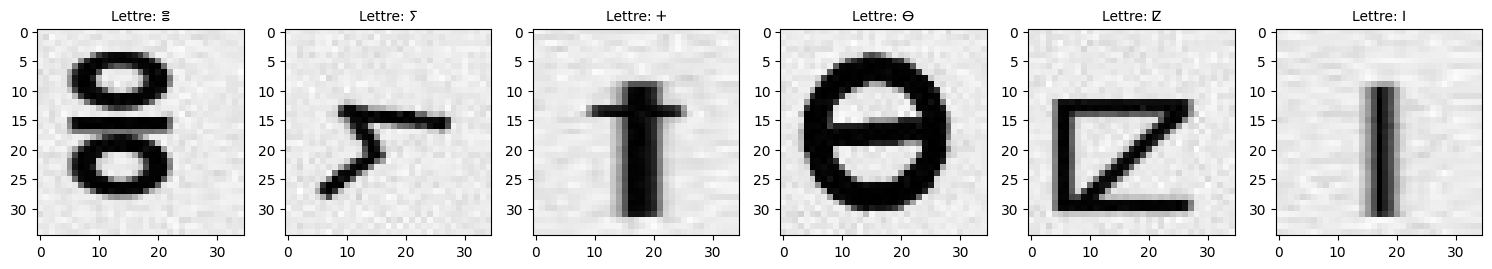

In [30]:
plot_number = 1
plt.figure(figsize=(15, 5))  # Adjust the size as needed

class_indices = {
    'ⴰ': 1, 'ⴱ': 2, 'ⵛ': 3, 'ⴷ': 4, 'ⴹ': 5, 'ⴻ': 6, 'ⴼ': 7, 'ⴳ': 8, 'ⵀ': 9, 'ⵉ': 10,
    'ⵊ': 11, 'ⴽ': 12, 'ⵍ': 13, 'ⵎ': 14, 'ⵏ': 15, 'ⵄ': 16, 'ⵃ': 17, 'ⵇ': 18, 'ⵔ': 19,
    'ⵕ': 20, 'ⵙ': 21, 'ⵚ': 22, 'ⵜ': 23, 'ⵟ': 24, 'ⵓ': 25, 'ⵖ': 26, 'ⵡ': 27, 'ⵅ': 28,
    'ⵢ': 29, 'ⵣ': 30, 'ⵥ': 31
}

classes = {v: k for k, v in class_indices.items()}

# Choose 3 random images from the test set to display
for i in np.random.randint(0, len(X), 6):
    plt.subplot(1, 6, plot_number)
    plt.grid(False)
    plt.imshow(X[i], cmap=plt.cm.binary)
    true_label = Y[i]
    plt.title(f"Lettre: {classes[true_label]}", fontsize=10)
    plt.tight_layout(pad=1.0)
    plot_number += 1
    
plt.show()

In [31]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [32]:
# Création du modèle
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Assurez-vous que la dimension est correcte pour des images en niveaux de gris
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_indices), activation='softmax')
])

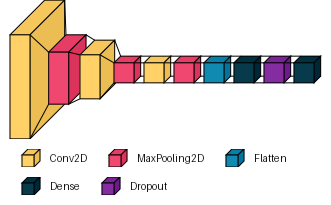

In [41]:
import visualkeras
visualkeras.layered_view(model, legend=True) # without custom font
visualkeras.layered_view(model, legend=True) # selected font